# 第一題

使用 The Boston Housing Dataset 中的 RM、LSTAT 及 CRIM 作為解釋變數，MDEV 為被解釋變數，建立多元線性迴歸模型：
- 不需要切分資料集。
- 利用梯度下降法求解模型參數，並假設梯度無封閉解。
- 將迭代運算次數及學習率分別設定為2500、0.001，權重向量的初始值皆設定為1。
- 每100次迭代運算完成後更新一次紀錄表並印出該次新增的紀錄。
- 紀錄表需紀錄迭代運算次數及損失數值。

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# waring抑止
import warnings
warnings.filterwarnings('ignore')

In [33]:
raw_df = pd.read_csv('BostonHousing.csv')
x_org = raw_df.values[:, :-1]
yt = raw_df.values[:, -1]
feature_names = raw_df.columns[:-1]

print('原始資料', x_org.shape, yt.shape)
print('特徵名稱：', feature_names)

cols_to_keep = ['rm', 'crim', 'lstat']
x_data = raw_df[cols_to_keep].values
print('過濾後資料形狀:', x_data.shape)

# 新增虛擬變數
x = np.insert(x_data, 0, 1.0, axis=1)
print('加入虛擬變數後', x.shape)

原始資料 (506, 13) (506,)
特徵名稱： Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat'],
      dtype='object')
過濾後資料形狀: (506, 3)
加入虛擬變數後 (506, 4)


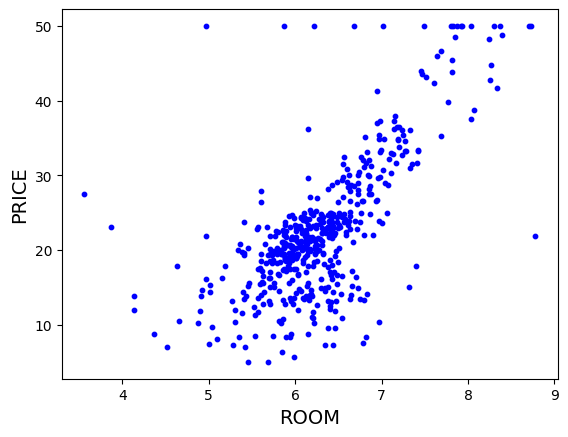

In [34]:
plt.scatter(x[:,1], yt, s=10, c='b')
plt.xlabel('ROOM', fontsize=14)
plt.ylabel('PRICE', fontsize=14)
plt.show()

In [35]:
# 初始化過程

# 資料系列總數
M  = x.shape[0]

# 輸入資料維數（包括虛擬變數）
D = x.shape[1]

# 重複次數
iters = 2500

# 學習率
alpha = 0.001

# 權重向量的初始值（所有值都設定為1）
w = np.ones(D)

# 用於記錄評估結果（僅記錄損失函數值）
history = np.zeros((0,2))

In [36]:
# 根據預測函數（1，x）的值計算預測值yp

def pred(x, w):
    return(x @ w)

In [37]:
# 重複循環
for k in range(iters):
    
    # 計算預測值（7.8.1）
    yp = pred(x, w)
    
    # 誤差計算（7.8.2）
    yd = yp - yt
    
    # 實現梯度下降（7.8.4）
    w = w - alpha * (x.T @ yd) / M
    
    # 計算並儲存資料以繪製學習曲線
    if ( k % 100 == 0):
        # 計算損失函數值（7.6.1）
        loss = np.mean(yd ** 2) / 2
        # 記錄計算結果
        history = np.vstack((history, np.array([k, loss])))
        # 螢幕顯示
        print( "iter = %d  loss = %f" % (k, loss))
        #print(w)    

iter = 0  loss = 203.401691
iter = 100  loss = 24.826409
iter = 200  loss = 16.268071
iter = 300  loss = 15.161431
iter = 400  loss = 15.018284
iter = 500  loss = 14.999724
iter = 600  loss = 14.997275
iter = 700  loss = 14.996909
iter = 800  loss = 14.996813
iter = 900  loss = 14.996752
iter = 1000  loss = 14.996695
iter = 1100  loss = 14.996639
iter = 1200  loss = 14.996582
iter = 1300  loss = 14.996526
iter = 1400  loss = 14.996470
iter = 1500  loss = 14.996415
iter = 1600  loss = 14.996359
iter = 1700  loss = 14.996303
iter = 1800  loss = 14.996247
iter = 1900  loss = 14.996192
iter = 2000  loss = 14.996136
iter = 2100  loss = 14.996081
iter = 2200  loss = 14.996025
iter = 2300  loss = 14.995970
iter = 2400  loss = 14.995914


# 第二題

使用 The Iris Flower Dataset 中的所有特徵作為解釋變數，花朵屬種作為被解釋變數，建立多元分類模型：
- 利用 scikit-learn 中的 train_test_split 切分訓練集和測試集，兩者各佔總樣本數的一半，並將 random_state 設定為123。
- 利用梯度下降法求解模型參數，並假設梯度無封閉解。
- 將迭代運算次數及學習率分別設定為2500、0.001，權重矩陣的初始值皆設定為1。
- 每100次迭代運算完成後更新一次紀錄表並印出該次新增的紀錄。
- 紀錄表需紀錄三種數值，分別為迭代運算次數、測試集損失數值及測試集預測準確率。

In [38]:
# 準備訓練數據
from sklearn.datasets import load_iris
iris = load_iris()
x_org, y_org = iris.data, iris.target

# 對於輸入數據，僅提取萼片長度（0）和花瓣長度（2）
x_select = x_org[:,[0,2]]
print('原始數據', x_select.shape, y_org.shape)

原始數據 (150, 2) (150,)


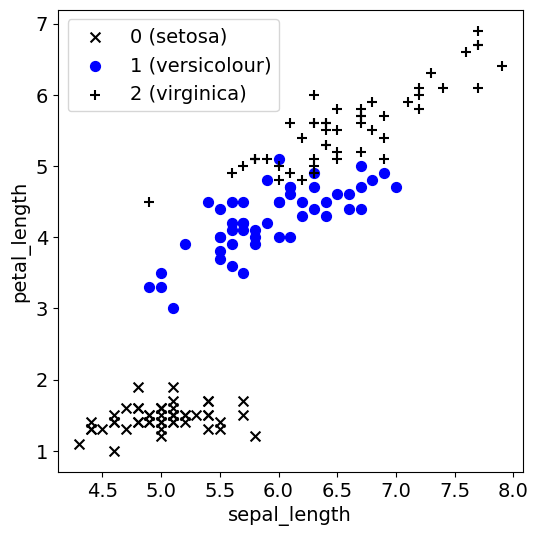

In [39]:
# 散布図の表示
x_t0 = x_select[y_org == 0]
x_t1 = x_select[y_org == 1]
x_t2 = x_select[y_org == 2]
plt.figure(figsize=(6,6))
plt.scatter(x_t0[:,0], x_t0[:,1], marker='x', c='k', s=50, label='0 (setosa)')
plt.scatter(x_t1[:,0], x_t1[:,1], marker='o', c='b', s=50, label='1 (versicolour)')
plt.scatter(x_t2[:,0], x_t2[:,1], marker='+', c='k', s=50, label='2 (virginica)')
plt.xlabel('sepal_length', fontsize=14)
plt.ylabel('petal_length', fontsize=14)
plt.xticks(size=14)
plt.yticks(size=14)
plt.legend(fontsize=14)
plt.show()

In [40]:
# 將 y 轉換為 One-hot 向量
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False,categories='auto')
y_work = np.c_[y_org]
y_all_one = ohe.fit_transform(y_work)
print('原始', y_org.shape)
print('2D', y_work.shape)
print('One Hot Vector化後', y_all_one.shape)

原始 (150,)
2D (150, 1)
One Hot Vector化後 (150, 3)


In [41]:
# 新增虛擬變數
x_all = np.insert(x_select, 0, 1.0, axis=1)
print(len(x_all))

150


In [42]:
# 分成訓練資料和驗證數據
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test, y_train_one, y_test_one = train_test_split(
    x_all, y_org, y_all_one, train_size=75, test_size=75, random_state=123)
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape, 
    y_train_one.shape, y_test_one.shape)

(75, 3) (75, 3) (75,) (75,) (75, 3) (75, 3)


In [43]:
# 選擇要學習的內容
x, yt  = x_train, y_train_one

In [44]:
# softmax関数 (9.7.3)
# softmax函數（9.7.3）
def softmax(x):
    x = x.T
    x_max = x.max(axis=0)
    x = x - x_max
    w = np.exp(x)
    return (w / w.sum(axis=0)).T

In [45]:
def pred(x, W):
    return softmax(x @ W)

In [ ]:
# 交叉熵函數）（9.5.1）
def cross_entropy(yt, yp):
    return -np.mean(np.sum(yt * np.log(yp), axis=1))

In [ ]:
# 評估模型的函數
from sklearn.metrics import accuracy_score

def evaluate(x_test, y_test, y_test_one, W):
    
    # 計算預測值（機率值）
    yp_test_one = pred(x_test, W)
    
    # 根據機率值得出預測類別 (0, 1, 2)
    yp_test = np.argmax(yp_test_one, axis=1)
    
    # 計算損失函數值
    loss = cross_entropy(y_test_one, yp_test_one)
    
    # 計算準確率
    score = accuracy_score(y_test, yp_test)
    return loss, score   

In [48]:
# 初期化処理

# 標本数
M  = x.shape[0]
# 入力次元数(ダミー変数を含む
D = x.shape[1]
# 分類先クラス数
N = yt.shape[1]

# 繰り返し回数
iters = 2500

# 学習率
alpha = 0.001

# 重み行列の初期設定(すべて1)
W = np.ones((D, N)) 
print(W)

# 評価結果記録用
history = np.zeros((0, 3))

[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]


In [49]:
#  メイン処理
for k in range(iters):
    
    # 予測値の計算 (9.7.1)　(9.7.2)
    yp = x @ W
    
    # 誤差の計算 (9.7.4)
    yd = yp - yt

    # 重みの更新 (9.7.5)
    W = W - alpha * (x.T @ yd) / M

    if (k % 100 == 0):
        loss, score = evaluate(x_test, y_test, y_test_one, W)
        history = np.vstack((history,
            np.array([k, loss, score])))
        print("epoch = %d loss = %f score = %f" 
            % (k, loss, score))

epoch = 0 loss = 1.097932 score = 0.266667
epoch = 100 loss = 1.061021 score = 0.266667
epoch = 200 loss = 1.031419 score = 0.600000
epoch = 300 loss = 1.005900 score = 0.626667
epoch = 400 loss = 0.983852 score = 0.626667
epoch = 500 loss = 0.964757 score = 0.653333
epoch = 600 loss = 0.948184 score = 0.786667
epoch = 700 loss = 0.933769 score = 0.813333
epoch = 800 loss = 0.921204 score = 0.826667
epoch = 900 loss = 0.910233 score = 0.866667
epoch = 1000 loss = 0.900635 score = 0.880000
epoch = 1100 loss = 0.892225 score = 0.906667
epoch = 1200 loss = 0.884845 score = 0.920000
epoch = 1300 loss = 0.878360 score = 0.946667
epoch = 1400 loss = 0.872654 score = 0.946667
epoch = 1500 loss = 0.867628 score = 0.960000
epoch = 1600 loss = 0.863195 score = 0.960000
epoch = 1700 loss = 0.859284 score = 0.946667
epoch = 1800 loss = 0.855828 score = 0.946667
epoch = 1900 loss = 0.852773 score = 0.960000
epoch = 2000 loss = 0.850070 score = 0.960000
epoch = 2100 loss = 0.847677 score = 0.960000


In [50]:
#損失関数値と精度の確認
print('初期状態: 損失関数:%f 精度:%f' 
    % (history[0,1], history[0,2]))
print('最終状態: 損失関数:%f 精度:%f' 
    % (history[-1,1], history[-1,2]))

初期状態: 損失関数:1.097932 精度:0.266667
最終状態: 損失関数:0.842012 精度:0.960000


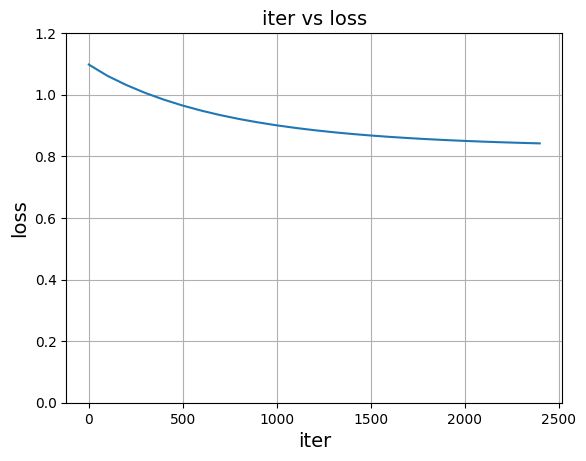

In [51]:
# 学習曲線の表示 (損失関数)
plt.plot(history[:,0], history[:,1])
plt.grid()
plt.ylim(0,1.2)
plt.xlabel('iter', fontsize=14)
plt.ylabel('loss', fontsize=14)
plt.title('iter vs loss', fontsize=14)
plt.show()

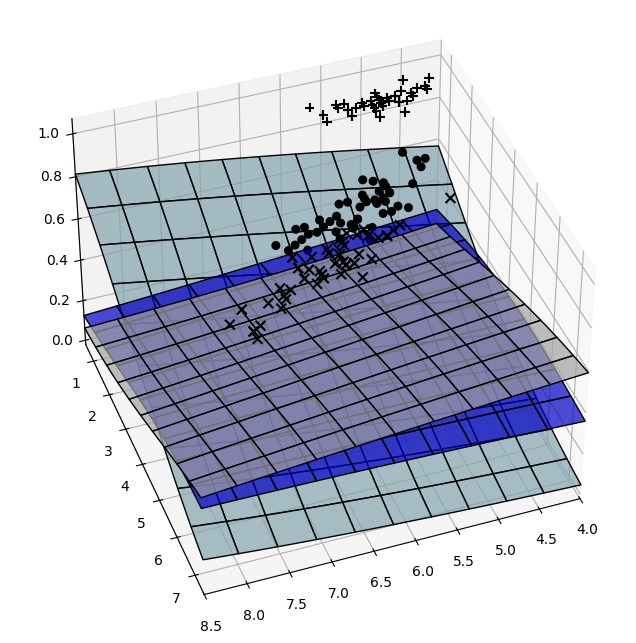

In [52]:
# 3次元表示
from mpl_toolkits.mplot3d import Axes3D
x1 = np.linspace(4, 8.5, 100)
x2 = np.linspace(0.5, 7.5, 100)
xx1, xx2 = np.meshgrid(x1, x2)
xxx = np.array([np.ones(xx1.ravel().shape), 
    xx1.ravel(), xx2.ravel()]).T
pp = pred(xxx, W)
c0 = pp[:,0].reshape(xx1.shape)
c1 = pp[:,1].reshape(xx1.shape)
c2 = pp[:,2].reshape(xx1.shape)
plt.figure(figsize=(8,8))
ax = plt.subplot(1, 1, 1, projection='3d')
ax.plot_surface(xx1, xx2, c0, color='lightblue', 
    edgecolor='black', rstride=10, cstride=10, alpha=0.7)
ax.plot_surface(xx1, xx2, c1, color='blue', 
    edgecolor='black', rstride=10, cstride=10, alpha=0.7)
ax.plot_surface(xx1, xx2, c2, color='lightgrey', 
    edgecolor='black', rstride=10, cstride=10, alpha=0.7)
ax.scatter(x_t0[:,0], x_t0[:,1], 1, s=50, alpha=1, marker='+', c='k')
ax.scatter(x_t1[:,0], x_t1[:,1], 1, s=30, alpha=1, marker='o', c='k')
ax.scatter(x_t2[:,0], x_t2[:,1], 1, s=50, alpha=1, marker='x', c='k')
ax.set_xlim(4,8.5)
ax.set_ylim(0.5,7.5)
ax.view_init(elev=40, azim=70)

In [53]:
# 決定境界用の１次関数定義
def d_bound(x, i, W):
    W1 = W[:,[2,0,1]]
    W2 = W - W1
    w = W2[:,i]
    v = -1/w[2]*(w[1]*x + w[0])
    return v

In [54]:
# x, yの描画領域計算
x_min = x_select[:,0].min()
x_max = x_select[:,0].max()
y_min = x_select[:,1].min()
y_max = x_select[:,1].max()
x_bound = np.array([x_min, x_max])

In [55]:
# 決定境界のyの値を計算
y0_bound = d_bound(x_bound, 0, W)
y1_bound = d_bound(x_bound, 1, W)
y2_bound = d_bound(x_bound, 2, W)

# 結果確認
print(y0_bound)
print(y1_bound)
print(y2_bound)

[2.85150385 5.0416988 ]
[2.66348482 4.7501304 ]
[3.50047753 6.04808744]


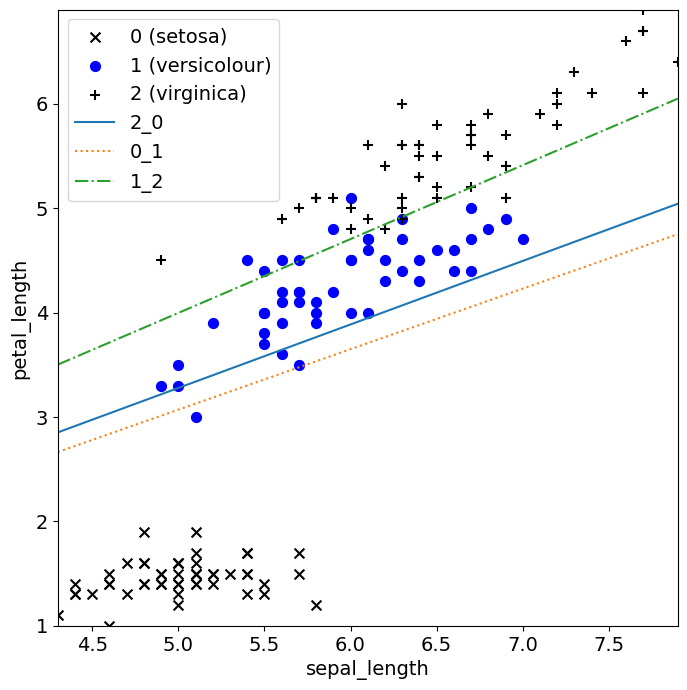

In [56]:
# 散布図と決定境界の標示

#グラフサイズ指定
plt.figure(figsize=(8,8))

# 元データをグループ分け
x_t0 = x_select[y_org == 0]
x_t1 = x_select[y_org == 1]
x_t2 = x_select[y_org == 2]

# xとyの範囲を明示的に指定
plt.axis([x_min, x_max, y_min, y_max])

#  散布図の表示
plt.scatter(x_t0[:,0], x_t0[:,1], marker='x', c='k', s=50, label='0 (setosa)')
plt.scatter(x_t1[:,0], x_t1[:,1], marker='o', c='b', s=50, label='1 (versicolour)')
plt.scatter(x_t2[:,0], x_t2[:,1], marker='+', c='k', s=50, label='2 (virginica)')

# 決定境界の標示
plt.plot(x_bound, y0_bound, label='2_0')
plt.plot(x_bound, y1_bound, linestyle=':',label='0_1')
plt.plot(x_bound, y2_bound,linestyle='-.',label='1_2')

# 軸ラベル設定
plt.xlabel('sepal_length', fontsize=14)
plt.ylabel('petal_length', fontsize=14)
plt.xticks(size=14)
plt.yticks(size=14)
plt.legend(fontsize=14)
plt.show()